In [1]:
from notebooks.figures import FONTSIZE

In [2]:
import torch
from transformers import AutoConfig

config = AutoConfig.from_pretrained("castorini/monobert-large-msmarco")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

EMBED_DIM = 26
THRESHOLD = 0.99

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 16, NUM_LAYERS: 24, HIDDEN_DIM: 4096


In [3]:
# LR = 1, alpha = 10, initial_masks = 3.0, Gumbel_Softmax
path = "/home/vast/target_dir/relevance-integrations/jobs/xpmir.learning.learner.learner/c25cc416373ffd1bf251d6edbae3c37d93d6dd87c338ed65b7f1ea1ec516708b/checkpoints/epoch-00000100/model.pth"

parameters = torch.load(path, map_location="cpu")

After masking, 6 heads are gone and 21.06% of the directions have been preserved.


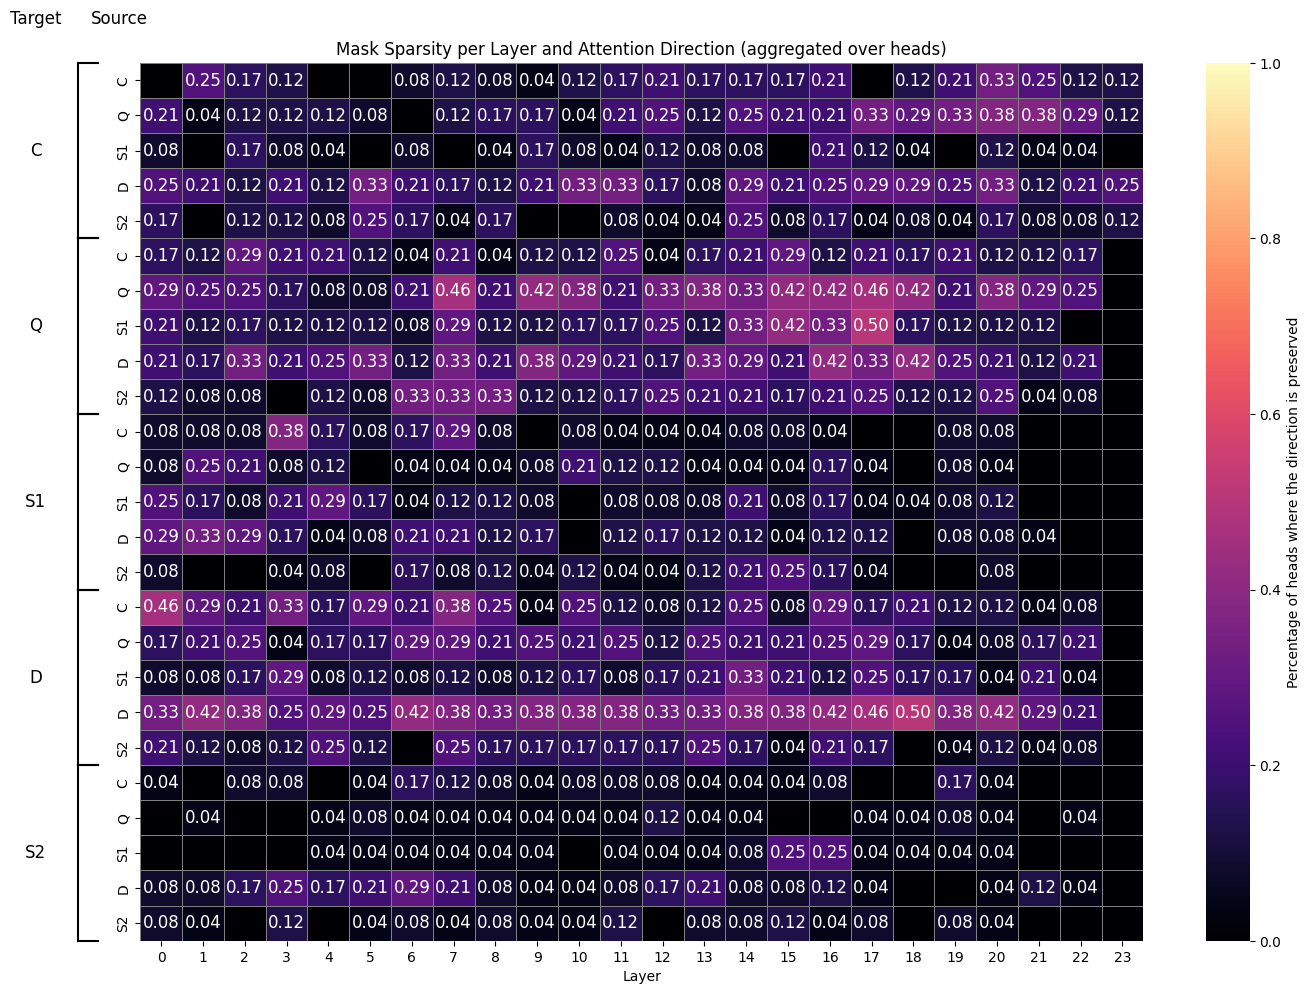

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import product
import re

# ------------------------------------------------------------------
# 1.  COLLECT ALL 144 MASK TENSORS (26-dim each)
# ------------------------------------------------------------------
pattern = re.compile(r"^masking_strategy\.masks_weights\.(\d+)\.weight$")
masks = {}   # (layer, head) -> 26-dim tensor

for name, tensor in parameters.items():
    m = pattern.match(name)
    if m:
        idx   = int(m.group(1))
        layer = idx // NUM_HEADS
        head  = idx % NUM_HEADS
        masks[(layer, head)] = tensor.float().cpu()

assert len(masks) == NUM_HEADS * NUM_LAYERS, f"Expected {NUM_HEADS * NUM_LAYERS} masks"

# ------------------------------------------------------------------
# 2.  STACK INTO [layers, heads, 26]
# ------------------------------------------------------------------

scores = torch.stack([masks[(l, h)] for l in range(NUM_LAYERS) for h in range(NUM_HEADS)])

# --------- Label setup ---------
INPUT_PARTS = ["C", "Q", "S1", "D", "S2"]
pairs = list(product(INPUT_PARTS, repeat=2))[:25]
targets, sources = zip(*pairs)

# y-tick labels: only source
yticks = [s for s in sources]

# --------- Compute sparsity ---------
if scores.shape[-1] == 2:
    scores = scores.view(NUM_LAYERS, NUM_HEADS, EMBED_DIM, 2) 
    # If the last dimension is 2, we use sigmoid on the first part
    scores = torch.nn.functional.softmax(scores, dim=-1)[:,:,:,0]
    kept = scores > THRESHOLD
else:
    scores = scores.view(NUM_LAYERS, NUM_HEADS, EMBED_DIM)
    sigmoid_scores =  torch.sigmoid(scores[:,:,:,0])  # [12, 12, 26]
    kept = sigmoid_scores > THRESHOLD

kept_count = kept.sum(dim=1)
# sparsity = 1 - kept_count / kept.shape[1]
# sparsity = sparsity[:, :25]  # shape: [12, 25]
heads_preserved = kept[:,:,:25].sum(dim=2).nonzero().shape[0]
print(f"After masking, {NUM_LAYERS * NUM_HEADS - heads_preserved} heads are gone and {kept_count.sum()/(NUM_LAYERS * NUM_HEADS * 25)*100:.2f}% of the directions have been preserved.")

# # --------- Plot heatmap ---------
# fig, ax = plt.subplots(figsize=(12, 8))
# sns.heatmap(
#     sparsity.T.numpy(),
#     cmap="magma_r",
#     vmin=0.4, vmax=1,
#     xticklabels=range(12),
#     yticklabels=yticks,
#     cbar_kws={"label": "Sparsity"},
#     linewidths=0.5,
#     linecolor='gray',
#     ax=ax
# )

kept_count = kept_count[: ,:25] / NUM_LAYERS
fig, ax = plt.subplots(figsize=(14, 10))
for i in range(kept_count.shape[0]):
    for j in range(kept_count.shape[1]):
        if float(kept_count[i, j].item()) > 0:
            ax.text(i + 0.5, j + 0.5, f"{float(kept_count[i, j].item()):.2f}", 
                    ha='center', va='center', color='white', fontsize=FONTSIZE) # if kept_count[i, j] < 6 else 'black'
sns.heatmap(
    kept_count.T.numpy(),
    cmap="magma",
    vmin=0, vmax=1.0,
    xticklabels=range(NUM_LAYERS),
    yticklabels=yticks,
    cbar_kws={"label": "Percentage of heads where the direction is preserved"},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

# --------- Add brackets and centered target labels ---------
for i, target in enumerate(INPUT_PARTS):
    y_start = i * 5
    y_end = y_start + 5
    y_center = y_start + 2.5

    # Bracket on the left
    ax.plot([-1.5, -1.5], [y_start, y_end], color='black', lw=1.5, clip_on=False)
    ax.plot([-1.5, -1.0], [y_start, y_start], color='black', lw=1.5, clip_on=False)
    ax.plot([-1.5, -1.0], [y_end, y_end],     color='black', lw=1.5, clip_on=False)

    # Target label centered
    ax.text(-2.5, y_center, target, va='center', ha='center', fontsize=FONTSIZE)

# --------- Add column headers: "Target" and "Source" ---------
# These are positioned in data coordinates (x=-2.5 and x=-0.5)
ax.text(-2.5, -1, "Target", ha='center', va='bottom', fontsize=FONTSIZE)
ax.text(-0.5, -1, "Source", ha='center', va='bottom', fontsize=FONTSIZE)
# --------- Final tweaks ---------
ax.set_ylabel("")  # remove default y-axis label
ax.set_xlabel("Layer")
ax.set_title("Mask Sparsity per Layer and Attention Direction (aggregated over heads)")
plt.tight_layout()
plt.savefig(f"./images/monobert_large_mask_sparsity_heatmap_threshold={THRESHOLD}.pdf", format='pdf')
plt.show()

In [6]:
list_of_indices = [[1,9],[15,13],[9,0],[11,13],[11,12],[16,1],[14,5],[22,4],[10,10],[2,0]]

In [7]:
d_to_q = scores[:,:,8]
for idx in list_of_indices:
    value = d_to_q[idx[0], idx[1]]
    print(f"d_to_q[{idx[0]}, {idx[1]}] = {value:.4g} {'>' if value > THRESHOLD else '<='} threshold ({THRESHOLD})")

d_to_q[1, 9] = 0.003438 <= threshold (0.99)
d_to_q[15, 13] = 0.9964 > threshold (0.99)
d_to_q[9, 0] = 0.9987 > threshold (0.99)
d_to_q[11, 13] = 1 > threshold (0.99)
d_to_q[11, 12] = 0.9986 > threshold (0.99)
d_to_q[16, 1] = 0.9974 > threshold (0.99)
d_to_q[14, 5] = 0.9922 > threshold (0.99)
d_to_q[22, 4] = 0.0005177 <= threshold (0.99)
d_to_q[10, 10] = 0.9997 > threshold (0.99)
d_to_q[2, 0] = 0.9492 <= threshold (0.99)


In [8]:
q_to_d = scores[:,:,16]
for idx in list_of_indices:
    value = q_to_d[idx[0], idx[1]]
    print(f"q_to_d[{idx[0]}, {idx[1]}] = {value:.4g} {'>' if value > THRESHOLD else '<='} threshold ({THRESHOLD})")

q_to_d[1, 9] = 0.9935 > threshold (0.99)
q_to_d[15, 13] = 1 > threshold (0.99)
q_to_d[9, 0] = 0.9895 <= threshold (0.99)
q_to_d[11, 13] = 0.9985 > threshold (0.99)
q_to_d[11, 12] = 0.9809 <= threshold (0.99)
q_to_d[16, 1] = 0.9923 > threshold (0.99)
q_to_d[14, 5] = 0.9997 > threshold (0.99)
q_to_d[22, 4] = 0.9968 > threshold (0.99)
q_to_d[10, 10] = 0.8546 <= threshold (0.99)
q_to_d[2, 0] = 0.01086 <= threshold (0.99)
